In [1]:
!pip install -q kaggle tensorflow opencv-python-headless

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_9e35668cba1f549dfc716347875e65ca"

!kaggle datasets download -d msambare/fer2013 -p /content/fer2013 --unzip

TRAIN_DIR = "/content/fer2013/train"
TEST_DIR = "/content/fer2013/test"

print("Classes found:", sorted(os.listdir(TRAIN_DIR)))

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 116MB/s]

Classes found: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
IMG_SIZE = 48
BATCH_SIZE = 64
NUM_CLASSES = 7
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale",
    batch_size=BATCH_SIZE, class_mode="categorical", subset="training",
    shuffle=True, classes=CLASS_NAMES
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale",
    batch_size=BATCH_SIZE, class_mode="categorical", subset="validation",
    shuffle=False, classes=CLASS_NAMES
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode="grayscale",
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False, classes=CLASS_NAMES
)

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [4]:
def build_emotion_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model


model = build_emotion_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,470,951 (5.61 MB)

 Trainable params: 1,469,543 (5.61 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [5]:
import tensorflow as tf

gpu_devices = tf.config.list_physical_devices('GPU')
if not gpu_devices:
    raise RuntimeError(
        "No GPU detected! Go to Runtime -> Change runtime type -> "
        "T4 GPU -> Save, then rerun Batches 1-4 before training."
    )
else:
    print("GPU detected, safe to train:", gpu_devices)

EPOCHS = 40

early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)
checkpoint = callbacks.ModelCheckpoint("/content/best_emotion_model.h5", monitor="val_accuracy", save_best_only=True, verbose=1)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

GPU detected, safe to train: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Epoch 1/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2193 - loss: 2.3642
Epoch 1: val_accuracy improved from None to 0.17469, saving model to /content/best_emotion_model.h5



Epoch 1: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 52s 91ms/step - accuracy: 0.2513 - loss: 2.1010 - val_accuracy: 0.1747 - val_loss: 1.9506 - learning_rate: 0.0010
Epoch 2/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3202 - loss: 1.7534
Epoch 2: val_accuracy improved from 0.17469 to 0.39365, saving model to /content/best_emotion_model.h5



Epoch 2: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.3436 - loss: 1.6894 - val_accuracy: 0.3937 - val_loss: 1.5748 - learning_rate: 0.0010
Epoch 3/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4021 - loss: 1.5372
Epoch 3: val_accuracy improved from 0.39365 to 0.41911, saving model to /content/best_emotion_model.h5



Epoch 3: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.4225 - loss: 1.4891 - val_accuracy: 0.4191 - val_loss: 1.5059 - learning_rate: 0.0010
Epoch 4/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4618 - loss: 1.3949
Epoch 4: val_accuracy improved from 0.41911 to 0.47594, saving model to /content/best_emotion_model.h5



Epoch 4: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.4739 - loss: 1.3709 - val_accuracy: 0.4759 - val_loss: 1.3718 - learning_rate: 0.0010
Epoch 5/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4989 - loss: 1.3137
Epoch 5: val_accuracy improved from 0.47594 to 0.51709, saving model to /content/best_emotion_model.h5


...


Epoch 10: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.5632 - loss: 1.1590 - val_accuracy: 0.5575 - val_loss: 1.1727 - learning_rate: 0.0010
Epoch 11/40
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5703 - loss: 1.1405
Epoch 11: val_accuracy did not improve from 0.55753
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.5711 - loss: 1.1391 - val_accuracy: 0.5488 - val_loss: 1.2353 - learning_rate: 0.0010
Epoch 12/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5793 - loss: 1.1139
Epoch 12: val_accuracy improved from 0.55753 to 0.57462, saving model to /content/best_emotion_model.h5



Epoch 12: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.5787 - loss: 1.1184 - val_accuracy: 0.5746 - val_loss: 1.1222 - learning_rate: 0.0010
Epoch 13/40
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5855 - loss: 1.1080
Epoch 13: val_accuracy improved from 0.57462 to 0.58264, saving model to /content/best_emotion_model.h5



Epoch 13: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.5841 - loss: 1.1080 - val_accuracy: 0.5826 - val_loss: 1.1096 - learning_rate: 0.0010
Epoch 14/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5929 - loss: 1.0922
Epoch 14: val_accuracy did not improve from 0.58264
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.5884 - loss: 1.0934 - val_accuracy: 0.5701 - val_loss: 1.1072 - learning_rate: 0.0010
Epoch 15/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5952 - loss: 1.0829
Epoch 15: val_accuracy did not improve from 0.58264
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.5939 - loss: 1.0869 - val_accuracy: 0.5760 - val_loss: 1.1094 - learning_rate: 0.0010
Epoch 16/40
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6019 - loss: 1.0653
Epoch 16: val_accuracy improved from 0.58264 to 0.58647, saving model to /content/best_emotion_model.h5



Epoch 16: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.5975 - loss: 1.0750 - val_accuracy: 0.5865 - val_loss: 1.0939 - learning_rate: 0.0010
Epoch 17/40
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5995 - loss: 1.0555
Epoch 17: val_accuracy improved from 0.58647 to 0.61611, saving model to /content/best_emotion_model.h5



Epoch 17: finished saving model to /content/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.5982 - loss: 1.0624 - val_accuracy: 0.6161 - val_loss: 1.0333 - learning_rate: 0.0010
Epoch 18/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5989 - loss: 1.0597
Epoch 18: val_accuracy did not improve from 0.61611
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.6028 - loss: 1.0549 - val_accuracy: 0.5851 - val_loss: 1.1860 - learning_rate: 0.0010
Epoch 19/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5938 - loss: 1.0709
Epoch 19: val_accuracy did not improve from 0.61611
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.5991 - loss: 1.0538 - val_accuracy: 0.5938 - val_loss: 1.0902 - learning_rate: 0.0010
Epoch 20/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6047 - loss: 1.0499
Epoch 20: val_accuracy did not improve from 0.61611
404/404 ━━━━━━━━━━━━━━━━━━━━ 26s 64ms/step - accuracy: 0.6011 - loss: 1.0590 - val_a

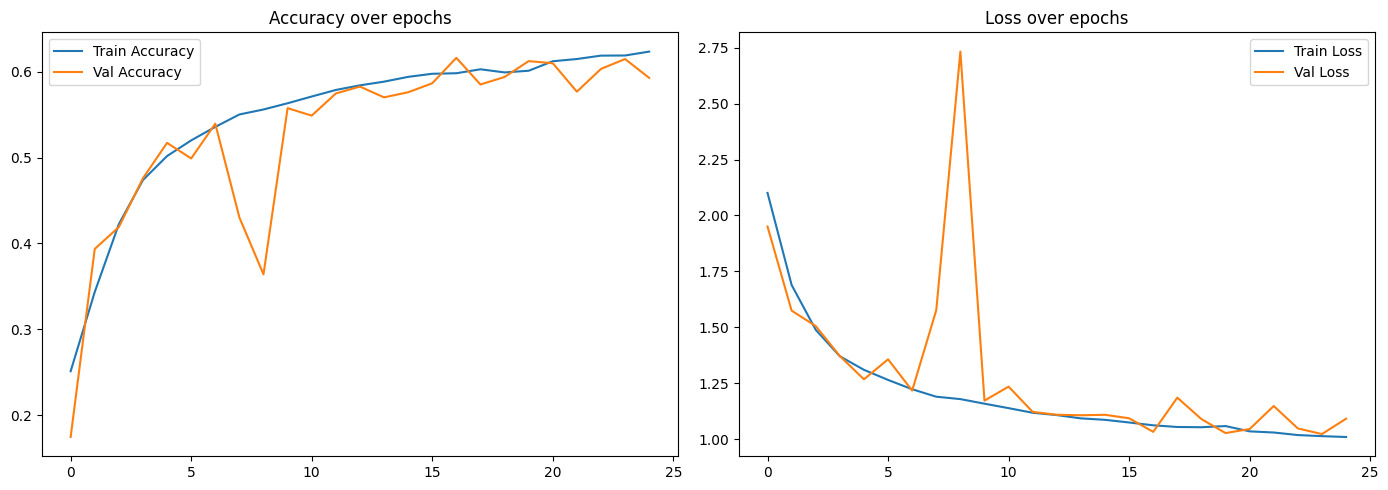

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over epochs")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.6151 - loss: 1.0228
Test Accuracy: 61.51%
Test Loss: 1.0228
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step
              precision    recall  f1-score   support

       angry       0.55      0.53      0.54       958
     disgust       0.59      0.38      0.46       111
        fear       0.42      0.39      0.41      1024
       happy       0.85      0.84      0.84      1774
         sad       0.50      0.45      0.47      1247
    surprise       0.66      0.82      0.73       831
     neutral       0.55      0.60      0.57      1233

    accuracy                           0.62      7178
   macro avg       0.59      0.57      0.58      7178
weighted avg       0.61      0.62      0.61      7178



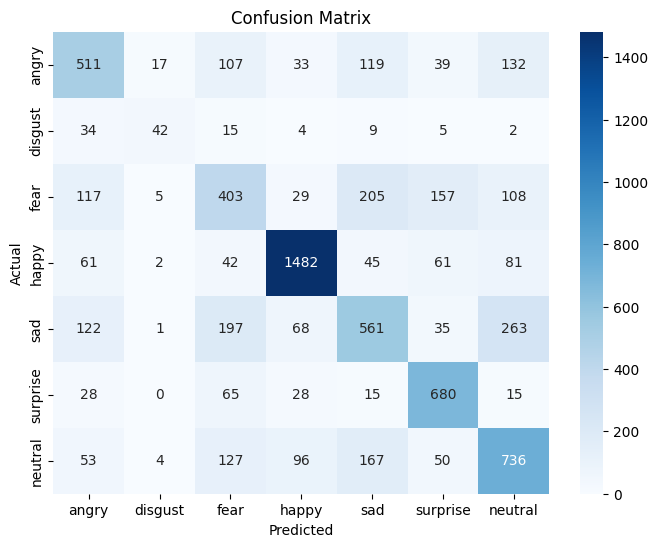

In [7]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
model.save("/content/emotion_model_final.h5")
print("Model saved to /content/emotion_model_final.h5")

from google.colab import files as colab_files
colab_files.download("/content/emotion_model_final.h5")

Model saved to /content/emotion_model_final.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import cv2
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL.Image
import io

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(",")[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    return cv2.imdecode(jpg_as_np, flags=1)

def bbox_to_bytes(bbox_array):
    bbox_PIL = PIL.Image.fromarray(bbox_array, "RGBA")
    iobuf = io.BytesIO()
    bbox_PIL.save(iobuf, format="png")
    return "data:image/png;base64," + b64encode(iobuf.getvalue()).decode("utf-8")

def video_stream():
    js = Javascript('''
        var video; var div = null; var stream; var captureCanvas;
        var imgElement; var labelElement; var pendingResolve = null; var shutdown = false;

        function removeDom() {
            stream.getVideoTracks()[0].stop();
            video.remove(); div.remove();
            video = null; div = null; stream = null; imgElement = null; captureCanvas = null; labelElement = null;
        }

        function onAnimationFrame() {
            if (!shutdown) { window.requestAnimationFrame(onAnimationFrame); }
            if (pendingResolve) {
                var result = "";
                if (!shutdown) {
                    captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
                    result = captureCanvas.toDataURL('image/jpeg', 0.8)
                }
                var lp = pendingResolve; pendingResolve = null; lp(result);
            }
        }

        async function createDom() {
            if (div !== null) { return stream; }
            div = document.createElement('div');
            div.style.border = '2px solid black'; div.style.padding = '3px'; div.style.width = '100%';
            document.body.appendChild(div);

            const modelOut = document.createElement('div');
            modelOut.innerHTML = "<span>Status:</span>";
            labelElement = document.createElement('span');
            labelElement.innerText = 'No data'; labelElement.style.fontWeight = 'bold';
            modelOut.appendChild(labelElement); div.appendChild(modelOut);

            video = document.createElement('video');
            video.style.display = 'block'; video.width = div.clientWidth - 6;
            video.setAttribute('playsinline', '');
            video.onclick = () => { shutdown = true; };
            stream = await navigator.mediaDevices.getUserMedia({ video: { facingMode: "environment" } });
            div.appendChild(video);

            imgElement = document.createElement('img');
            imgElement.style.position = 'absolute'; imgElement.style.zIndex = 1;
            imgElement.onclick = () => { shutdown = true; };
            div.appendChild(imgElement);

            const instruction = document.createElement('div');
            instruction.innerHTML = '<span style="color: red; font-weight: bold;">Click here or on the video to stop</span>';
            div.appendChild(instruction);
            instruction.onclick = () => { shutdown = true; };

            video.srcObject = stream; await video.play();
            captureCanvas = document.createElement('canvas');
            captureCanvas.width = 640; captureCanvas.height = 480;
            window.requestAnimationFrame(onAnimationFrame);
            return stream;
        }

        async function stream_frame(label, imgData) {
            if (shutdown) { removeDom(); shutdown = false; return ''; }
            var preCreate = Date.now();
            stream = await createDom();
            var preShow = Date.now();
            if (label != "") { labelElement.innerHTML = label; }
            if (imgData != "") {
                var videoRect = video.getClientRects()[0];
                imgElement.style.top = videoRect.top + "px";
                imgElement.style.left = videoRect.left + "px";
                imgElement.style.width = videoRect.width + "px";
                imgElement.style.height = videoRect.height + "px";
                imgElement.src = imgData;
            }
            var preCapture = Date.now();
            var result = await new Promise(function(resolve, reject) { pendingResolve = resolve; });
            shutdown = false;
            return { 'create': preShow - preCreate, 'show': preCapture - preShow, 'capture': Date.now() - preCapture, 'img': result };
        }
        ''')
    display(js)

def video_frame(label, bbox):
    return eval_js('stream_frame("{}", "{}")'.format(label, bbox))

def run_webcam_emotion_detection():
    video_stream()
    label_html = "Detecting emotions..."
    bbox = ""

    while True:
        js_reply = video_frame(label_html, bbox)
        if not js_reply:
            break

        img = js_to_image(js_reply["img"])
        overlay = np.zeros([480, 640, 4], dtype=np.uint8)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

        detected_text = []
        for (x, y, w, h) in faces:
            face_roi = gray[y:y + h, x:x + w]
            face_roi = cv2.resize(face_roi, (IMG_SIZE, IMG_SIZE))
            face_roi = face_roi.astype("float32") / 255.0
            face_roi = np.expand_dims(face_roi, axis=(0, -1))

            preds = model.predict(face_roi, verbose=0)[0]
            emotion_idx = int(np.argmax(preds))
            emotion_label = CLASS_NAMES[emotion_idx]
            confidence = float(preds[emotion_idx]) * 100

            cv2.rectangle(overlay, (x, y), (x + w, y + h), (0, 255, 0, 255), 2)
            cv2.putText(overlay, f"{emotion_label} ({confidence:.0f}%)", (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0, 255), 2)
            detected_text.append(f"{emotion_label} ({confidence:.0f}%)")

        label_html = "Detected: " + ", ".join(detected_text) if detected_text else "No face detected"
        bbox = bbox_to_bytes(overlay)

# Run this to start the live demo:
run_webcam_emotion_detection()

<IPython.core.display.Javascript object>

/tmp/ipykernel_1104/436145134.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  bbox_PIL = PIL.Image.fromarray(bbox_array, "RGBA")
